###  Player Auction Price Predictor

##### Problem Statement:
The goal of this model is to predict a player's **IPL auction price** using their historical performance statistics.

##### Target Variable:
`sold_price` (Amount column from auction dataset)

##### Features:
From deliveries dataset:
* total_runs
* batting_average
* strike_rate
* total_wickets
* bowling_economy
* bowling_average
* matches_played

From auction dataset:
* player_type (Role)

##### Model Type:
Regression


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
from src.feature_engineering import (
    compute_batting_stats,
    compute_bowling_stats,
    compute_matches_played
)

In [3]:
deliveries = pd.read_csv("../data/deliveries.csv")
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
auction = pd.read_csv("../data/player_auction.csv")    
auction.head()

,Player,Role,Amount,Team,Year,Player Origin
0,Aaron Finch,Batsman,40000000,Sunrisers Hyderabad,2014.0,Overseas
1,Aaron Finch,Batsman,32000000,Mumbai Indians,2015.0,Overseas
2,Aaron Finch,Batsman,10000000,Gujarat Lions,2016.0,Overseas
3,Aaron Finch,Batsman,62000000,Kings XI Punjab,2018.0,Overseas
4,Aaron Finch,Batsman,44000000,Royal Challengers Bangalore,2020.0,Overseas


In [5]:
batting_stats = compute_batting_stats(deliveries)
bowling_stats = compute_bowling_stats(deliveries)
matches_played = compute_matches_played(deliveries)

In [6]:
#merge player stats 
player_stats = batting_stats.merge(
    bowling_stats,
    left_index=True,
    right_index=True,
    how="outer"
)

player_stats = player_stats.merge(
    matches_played,
    left_on="batter",
    right_on="player",
    how="left"
)

#player_stats.drop(columns=["batter"], inplace=True)
player_stats.rename(columns={"player": "Player"}, inplace=True)

numeric_cols = player_stats.select_dtypes(include=np.number).columns
player_stats[numeric_cols] = player_stats[numeric_cols].fillna(0)


In [7]:
player_stats.head()

,total_runs,balls_faced,dismissals,batting_average,strike_rate,total_wickets,runs_conceded,balls_bowled,overs,bowling_economy,bowling_average,Player,matches_played
0,280.0,196.0,15.0,18.666667,142.857143,19.0,400.0,270.0,45.000000,8.888889,21.052632,A Ashish Reddy,23.0
1,634.0,505.0,26.0,24.384615,125.544554,2.0,37.0,25.0,4.166667,8.880000,18.500000,A Badoni,35.0
2,4.0,7.0,0.0,4.000000,57.142857,11.0,245.0,234.0,39.000000,6.282051,22.272727,A Chandila,2.0
3,53.0,75.0,6.0,8.833333,70.666667,0.0,0.0,0.0,0.000000,0.000000,0.000000,A Chopra,6.0
4,25.0,20.0,1.0,25.000000,125.000000,5.0,144.0,108.0,18.000000,8.000000,28.800000,A Choudhary,3.0


In [8]:
#merge auction
df = auction.merge(player_stats, on="Player", how="left")

In [9]:
df.head()

,Player,Role,Amount,Team,Year,Player Origin,total_runs,balls_faced,dismissals,batting_average,strike_rate,total_wickets,runs_conceded,balls_bowled,overs,bowling_economy,bowling_average,matches_played
0,Aaron Finch,Batsman,40000000,Sunrisers Hyderabad,2014.0,Overseas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Finch,Batsman,32000000,Mumbai Indians,2015.0,Overseas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron Finch,Batsman,10000000,Gujarat Lions,2016.0,Overseas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aaron Finch,Batsman,62000000,Kings XI Punjab,2018.0,Overseas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aaron Finch,Batsman,44000000,Royal Challengers Bangalore,2020.0,Overseas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
features = [
    "total_runs",
    "batting_average",
    "strike_rate",
    "total_wickets",
    "bowling_economy",
    "bowling_average",
    "matches_played"
]

X = df[features]
X = X.fillna(0)

y = df['Amount']

In [11]:
#split the dataset into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [13]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)
print("MAE:", mae)

RMSE: 27561048.00635522
R2: -0.12210938892548406
MAE: 19614218.68462815


### Model 2- Ridge Regression
Ridge Regression is an extension of Linear Regression that applies **L2 regularization** to reduce overfitting.
In datasets with correlated features (such as total runs, strike rate, and matches played), standard linear regression coefficients can become unstable. Ridge regression penalizes large coefficients and helps produce a more stable model.

##### Why Use Ridge Regression?
* Reduces model variance
* Handles multicollinearity between features
* Often improves generalization performance compared to standard linear regression

In this step, we train a Ridge Regression model and compare its performance with the baseline Linear Regression model.

In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

In [15]:
r2_ridge= r2_score(y_test, pred_ridge)
rmse_ridge= np.sqrt(mean_squared_error(y_test, pred_ridge))

print("R2: ", r2_ridge)
print("RMSE: ", rmse_ridge)

R2:  -0.12209680672863743
RMSE:  27560893.485099602


### Model 3 — Random Forest Regressor
Unlike linear models, Random Forest can capture non-linear relationships and complex interactions between features, making it well suited for predicting player auction prices based on performance statistics.

##### Why Use Random Forest?
* Captures complex and non-linear relationships between features
* Reduces overfitting by averaging predictions across multiple trees
* Provides feature importance scores to understand which variables influence predictions most

In this step, we train a Random Forest Regressor and compare its performance with the previous models to determine whether a more complex model improves prediction accuracy.

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [17]:
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)

print("RMSE:", rmse_rf)
print("R2:", r2_rf)
print("MAE:", mae_rf)

RMSE: 27882341.804234523
R2: -0.14842393352420302
MAE: 20210554.586134855


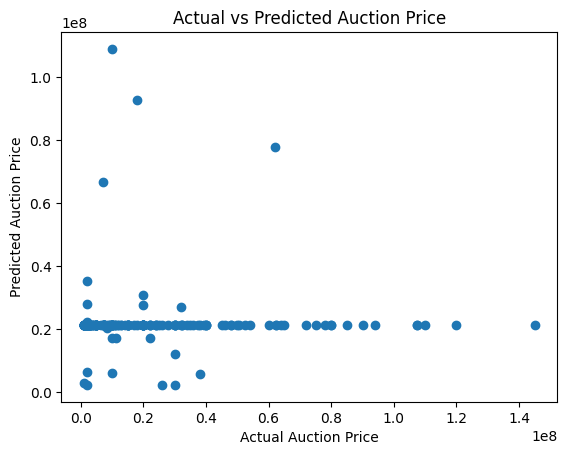

In [18]:
plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Auction Price")
plt.ylabel("Predicted Auction Price")
plt.title("Actual vs Predicted Auction Price")

plt.show()

In [19]:
import joblib

joblib.dump(rf, "../models/auction_price_model.pkl")

['../models/auction_price_model.pkl']